In [5]:
from astropy.io import fits
from scipy.io import readsav
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler

import tools as t

In [6]:
data = torch.load("../data/PCA/TS1/t_0.pt")
data['rv']

/tmp/ipykernel_1659487/3228788404.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("../data/PCA/TS1/t_0.pt")


np.float64(0.0703277155342828)

In [7]:
# Parameters

N = 3686
M = 20
TS = 1

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_1659487/1897771005.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [13]:
batch_size = 32

# Chronological train/test split

train_size = int(0.7 * N)
val_size = int(0.1 * N)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(X_train.mean(dim=0))
print(X_train.std(dim=0))

print(((X_train - X_train.mean(dim=0)) / X_train.std(dim=0)).std(dim=0))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Validation X shape:", X_val.shape)
print("Validation y shape:", y_val.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# Scaling scores
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_val_scaled = scaler.transform(X_val.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create Datasets
# Pair the rows of X with the corresponding rows of y

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoaders
# takes a Dataset and gives samples to the model in batches

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # The model sees the same 80% of the data, but in a different order each epoch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # There's no benefit to shuffling it because we're not updating the model during testing
)

tensor([ 2.4282e-06,  5.4145e-07,  4.5847e-07, -3.4212e-08, -7.5027e-08,
        -9.5540e-08,  2.6100e-08, -3.4410e-08, -1.3740e-08, -1.7269e-09,
         2.4896e-09, -4.9528e-10, -1.9037e-09, -6.6627e-10, -5.5762e-10,
        -1.7984e-10, -4.2695e-11,  1.2535e-10, -7.1267e-11,  1.5260e-10])
tensor([6.1061e-05, 2.2811e-05, 4.5990e-06, 3.8325e-06, 1.1054e-06, 8.0697e-07,
        2.9315e-07, 2.7373e-07, 2.0625e-07, 1.0881e-07, 6.0877e-08, 5.5145e-08,
        2.9016e-08, 2.8231e-08, 1.2416e-08, 1.1691e-08, 1.0634e-08, 1.0216e-08,
        9.9731e-09, 9.9835e-09])
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000])
Train X shape: torch.Size([2580, 20])
Train y shape: torch.Size([2580, 1])
Validation X shape: torch.Size([368, 20])
Validation y shape: torch.Size([368, 1])
Test X shape: torch.Size([738, 20])
Test y shape: torch.Size([738, 1])


In [ ]:
print(X_train.mean(dim=0))  # dim = 0 to calculate the mean of each column (i.e. of each PC)
print(X_train.std(dim=0))

tensor([-8.8714e-09,  7.3928e-10,  2.2178e-09,  2.9571e-09,  4.4357e-09,
         4.9902e-09,  1.4786e-09,  1.4046e-08,  8.1321e-09,  5.5446e-09,
        -6.6535e-09, -7.3928e-09, -2.9571e-09, -1.4786e-08, -6.0991e-09,
         2.9571e-09,  9.6107e-09,  0.0000e+00,  1.4786e-09,  6.2839e-09])
tensor([1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002,
        1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002,
        1.0002, 1.0002])


In [ ]:
# Model
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),

    nn.Linear(32, 16),
    nn.ReLU(),
    
    nn.Linear(16, 1)
)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

# Scheduler: if validation loss stops improving, PyTorch reduces the learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=20
)

# Early stopping parameters
patience = 50
best_val_loss = float("inf")
epochs_without_improvement = 0

# Store the parameters of the best model
best_model_state = copy.deepcopy(model.state_dict())

# Training
epochs = 1000
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    # Average validation loss
    val_loss /= len(val_loader)

    # Early stopping
    if val_loss < best_val_loss:
        # Validation loss improved
        best_val_loss = val_loss
        epochs_without_improvement = 0
        # Save best model
        best_model_state = copy.deepcopy(model.state_dict())

    else:
        # No improvement
        epochs_without_improvement += 1

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}, "
            f"val loss = {val_loss:.4f}"
        )

    # Stop if validation loss hasn't improved
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}. "
        )
        break

    # Scheduler
    scheduler.step(val_loss)
    
# Restore best model
model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 0: train loss = 0.8888, val loss = 0.8261
Epoch 100: train loss = 0.0279, val loss = 0.0337
Epoch 200: train loss = 0.0247, val loss = 0.0327

Early stopping at epoch 280. 
Best validation loss: 0.0325


In [28]:
# Testing
model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)

        all_predictions.append(y_pred)
        all_targets.append(y_batch)

# Combine all batches
y_pred = torch.cat(all_predictions).squeeze().numpy()
y_true = torch.cat(all_targets).squeeze().numpy()

# Test loss
test_loss = np.mean((y_pred - y_true) ** 2)
print(f"Test MSE = {test_loss:.4f}")

Test MSE = 0.0363


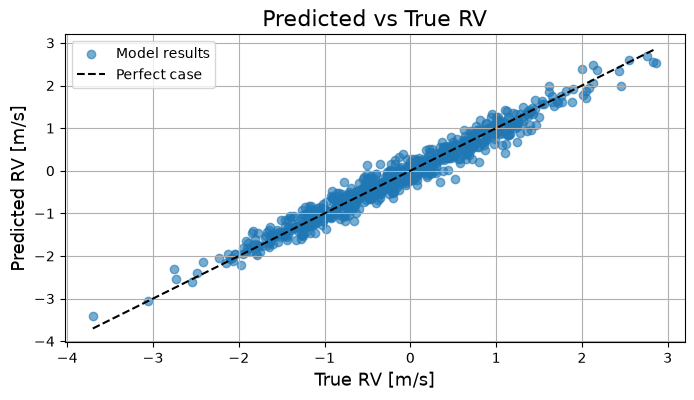

Standard deviation of the predicted RVs: 0.9503731727600098
Standard deviation of the test RVs: 0.9773247241973877


In [31]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.scatter(y_true, y_pred, alpha=0.6, label='Model results')

# Perfect-prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], '--', color='k', label='Perfect case')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.set_title('Predicted vs True RV', size=16)
ax.grid(True)
#ax.axis('equal')
ax.legend()
plt.show()

print(f'Standard deviation of the predicted RVs: {y_pred.std()}')
print(f'Standard deviation of the test RVs: {y_test.std()}')

In [93]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334
